# 04 — Appendix experiments

Experiments outside the main story (`02_results`), each changing **one thing** in the protocol and rerunning every
tested model with otherwise identical settings (`python -m src.train <model> <input> --<option>`; results in their own
folder under `outputs/results/`).

1. **Non-overlapping windows** — training stride 150 instead of 10.
2. **Unseen recordings** — protocol B (the papers' held-out recordings).

## 0. Setup

In [1]:
import sys; sys.path.insert(0, "..")
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from src.data import LEGS, TEST_RECS_B, labels, load_recordings, split, split_b

RESULTS = Path("../outputs/results")
MODELS = ["ridge_current", "ridge_window_log", "ridge_feat_all", "svm_linear_feat_all", "krr_feat_all",
          "svm_rbf_feat_all", "tree_feat_all", "rf_feat_all", "gb_feat_all"]
SHORT = {"ridge_current": "ridge, current", "ridge_window_log": "ridge, window", "ridge_feat_all": "ridge, features",
         "svm_linear_feat_all": "linear SVM", "krr_feat_all": "kernel ridge", "svm_rbf_feat_all": "RBF SVM",
         "tree_feat_all": "decision tree", "rf_feat_all": "random forest", "gb_feat_all": "gradient boosting",
         "ridge_10k_feat_all": "ridge, features, 10k", "svm_linear_10k_feat_all": "linear SVM, 10k",
         "gb_10k_feat_all": "gradient boosting, 10k"}
recs = load_recordings()

def load(folder="", models=MODELS):
    """{model: (result json, test predictions)} for the runs saved in outputs/results/<folder>."""
    d = RESULTS / folder
    return {m: (json.loads((d / f"{m}.json").read_text()), np.load(d / f"{m}_test_pred.npy"))
            for m in models if (d / f"{m}.json").exists()}

def rates(p, y):
    return {"false contact": ((p == 1) & (y == 0)).sum() / (y == 0).sum(),
            "missed contact": ((p == 0) & (y == 1)).sum() / (y == 1).sum()}

def per_recording(p, ends, y):
    """Test F1 per ground recording; false-contact rate for the air recordings."""
    out, i = {}, 0
    for name, e in ends.items():
        yy, q = y[i:i + len(e)], p[i:i + len(e)]
        i += len(e)
        out[name] = (np.mean([f1_score(yy[:, k], q[:, k], zero_division=0) for k in range(4)])
                     if yy.any() else q.mean())
    return pd.Series(out)

def best_params(r):
    b = max(r["validation"], key=lambda v: v["val_f1"])
    return ", ".join(f"{k.split('__')[-1]}={v:g}" if not isinstance(v, str) else f"{k.split('__')[-1]}={v}"
                     for k, v in b["params"].items())

## 1. Non-overlapping windows (training stride 150)

Same split, models, grids and refit as the main results; **train and validation windows taken every 150 steps instead of
every 10** — consecutive windows no longer overlap. Test unchanged (every timestep).
- Train / val / refit windows: 4,707 / 997 / 5,704 (stride 10: 70,476 / 14,882 / 85,358).
- Kernel models were already capped at 10k windows; now **every model sees the same 5.7k windows** (the `_10k`
  references would be identical to the full models and are not rerun).
- Validation has 997 windows instead of 14,882 → noisier selection; validation scores are not comparable across strides.

In [2]:
test_ends = split(recs)["test"]
y_test = labels(recs, test_ends)
s10, s150 = load(), load("stride150")
refit_windows = {m: (10_000 if m in ("krr_feat_all", "svm_rbf_feat_all") else 85_358) for m in MODELS}
cmp = pd.DataFrame({SHORT[m]: {
    "refit windows (stride 10)": refit_windows[m], "refit windows (stride 150)": 5_704,
    "F1 stride 10": s10[m][0]["test"]["f1"], "F1 stride 150": s150[m][0]["test"]["f1"],
    "change [points]": 100 * (s150[m][0]["test"]["f1"] - s10[m][0]["test"]["f1"]),
    **{f"{k} (10)": v for k, v in rates(s10[m][1], y_test).items()},
    **{f"{k} (150)": v for k, v in rates(s150[m][1], y_test).items()}} for m in MODELS}).T
cmp.round(4)

,refit windows (stride 10),refit windows (stride 150),F1 stride 10,F1 stride 150,change [points],false contact (10),missed contact (10),false contact (150),missed contact (150)
"ridge, current",85358.0,5704.0,0.8404,0.8373,-0.3129,0.0601,0.1888,0.0608,0.1930
"ridge, window",85358.0,5704.0,0.9297,0.9211,-0.8584,0.0327,0.0749,0.0345,0.0878
"ridge, features",85358.0,5704.0,0.9463,0.9418,-0.4523,0.0317,0.0455,0.0332,0.0514
linear SVM,85358.0,5704.0,0.9519,0.9389,-1.3007,0.0278,0.0417,0.0363,0.0514
kernel ridge,10000.0,5704.0,0.9558,0.9529,-0.2825,0.0249,0.0395,0.0275,0.0402
RBF SVM,10000.0,5704.0,0.9528,0.9486,-0.4269,0.0273,0.0408,0.0276,0.0483
decision tree,85358.0,5704.0,0.9396,0.8981,-4.1498,0.0315,0.0585,0.0554,0.0953
random forest,85358.0,5704.0,0.9668,0.9521,-1.4677,0.0177,0.0315,0.0234,0.0492
gradient boosting,85358.0,5704.0,0.9720,0.9583,-1.3692,0.0160,0.0244,0.0229,0.0381


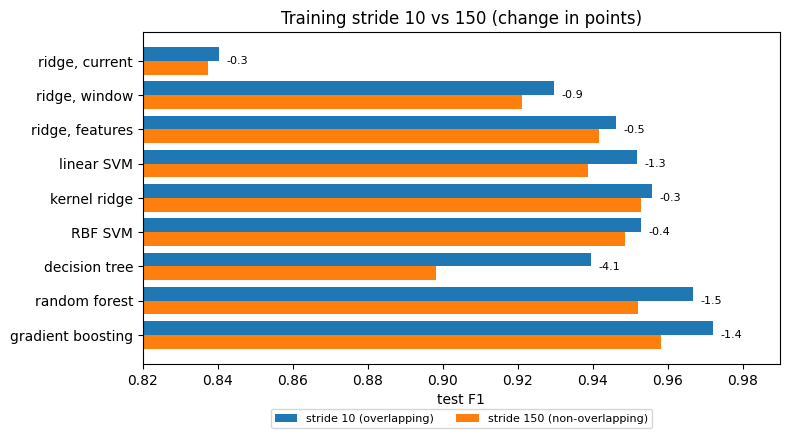

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
yy = np.arange(len(cmp))
ax.barh(yy - 0.2, cmp["F1 stride 10"], 0.4, label="stride 10 (overlapping)")
ax.barh(yy + 0.2, cmp["F1 stride 150"], 0.4, label="stride 150 (non-overlapping)")
for i, (a, b) in enumerate(zip(cmp["F1 stride 10"], cmp["F1 stride 150"])):
    ax.text(max(a, b) + 0.002, i, f"{100 * (b - a):+.1f}", va="center", fontsize=8)
ax.set_yticks(yy, cmp.index); ax.invert_yaxis(); ax.set_xlim(0.82, 0.99); ax.set_xlabel("test F1")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8); ax.set_title("Training stride 10 vs 150 (change in points)")
plt.tight_layout(); plt.show()

In [4]:
pd.DataFrame({SHORT[m]: {"stride 10": best_params(s10[m][0]), "stride 150": best_params(s150[m][0])}
              for m in MODELS}).T.rename_axis("chosen hyperparameters")

,stride 10,stride 150
chosen hyperparameters,,
"ridge, current",alpha=0.001,alpha=0.01
"ridge, window",alpha=0.1,alpha=10
"ridge, features",alpha=0.1,alpha=10
linear SVM,C=0.3,C=0.01
kernel ridge,"alpha=0.03, gamma_scale=0.3","alpha=0.1, gamma_scale=0.2"
RBF SVM,"C=10, gamma_scale=0.3","C=10, gamma_scale=0.3"
decision tree,min_samples_leaf=50,min_samples_leaf=1
random forest,"max_features=0.1, min_samples_leaf=1","max_features=0.2, min_samples_leaf=1"
gradient boosting,"max_iter=800, max_leaf_nodes=63","max_iter=400, max_leaf_nodes=63"


In [5]:
# change per recording (test F1 points; air recordings: change in false-contact rate)
sel = ["ridge_feat_all", "krr_feat_all", "tree_feat_all", "rf_feat_all", "gb_feat_all"]
(100 * pd.DataFrame({SHORT[m]: per_recording(s150[m][1], test_ends, y_test) - per_recording(s10[m][1], test_ends, y_test)
                     for m in sel})).round(1)

,"ridge, features",kernel ridge,decision tree,random forest,gradient boosting
air_jumping_gait,0.0,0.0,0.6,0.0,0.0
air_walking_gait,0.2,0.0,3.7,0.0,0.0
asphalt_road,0.2,0.3,-2.7,-0.6,-1.2
old_asphalt_road,-0.4,-0.4,-5.0,-1.3,-2.0
concrete_difficult_slippery,-0.6,-0.4,-4.7,-0.7,-0.9
concrete_galloping,-1.4,-1.4,-8.7,-9.2,-5.7
concrete_left_circle,-0.0,-0.3,-1.6,-0.5,-0.5
concrete_pronking,-0.6,-0.0,-4.7,-1.0,-0.6
concrete_right_circle,-0.2,-0.2,-1.7,-0.9,-0.8
forest,-0.8,-0.0,-3.3,-1.3,-1.5


- **Every model loses with non-overlapping windows**: from −0.3 (kernel ridge, ridge on the current timestep) to −4.1
  points (single tree). The 90% "redundant" overlapping windows are not harmless duplicates — they are free extra data.
- **The loss follows how much data a model used and how much it can use**:
  - kernel models lose little (−0.3 / −0.4): they already had only 10k windows (now 5.7k, ×0.57);
  - ridge loses little despite 15× fewer windows (−0.3 to −0.9): a linear boundary needs few samples;
  - the data-hungry models lose most: linear SVM −1.3 (the hinge is decided by the windows near the boundary — the same
    model gained +1.0 from 10k → 70k), random forest −1.5, boosting −1.4, single tree −4.1.
- **Ranking at stride 150**: boosting still best (0.958), but kernel ridge (0.953) and the forest (0.952) close in —
  boosting's lead over kernel ridge drops from 1.6 to 0.5 points, consistent with the main results, where ~1.0 of
  that lead came from the extra data (`gb_10k`).
- **Both errors grow**, false contacts too: boosting 1.6% → 2.3%, forest 1.8% → 2.3%, single tree 3.2% → 5.5%.
- **Galloping suffers most** (forest −9.2, tree −8.7, boosting −5.7, ridge and kernel ridge −1.4): the only
  galloping recording, so at stride 150 the whole gait is learned from ~230 training windows.
- **With less data, validation picks stronger regularization**: ridge α 0.1 → 10, linear SVM C 0.3 → 0.01 (smaller C =
  stronger), kernel ridge α 0.03 → 0.1 with a smoother kernel (s 0.3 → 0.2), boosting 800 → 400 trees. RBF SVM
  unchanged. The single tree goes the other way (leaf size 50 → 1): with 5.7k windows and no near-duplicates, leaves
  of 50 are too coarse.
- **Conclusion**: confirms the Phase 2 choice — overlapping windows (stride 10) cost nothing and help every model, most
  of all the flexible ones; non-overlapping windows only lose information.

## 2. Unseen recordings — protocol B

The papers' split: test = every window of `air_jumping_gait`, `concrete_pronking`, `concrete_right_circle`, `forest`,
`small_pebble` — **recordings never seen in training**; the other 10 recordings → first 85% train, gap, last 15%
validation (`split_b`, `src/data.py`). Same models, grids and refit as protocol A.
Test: 375,162 windows (5 whole recordings) vs 148,763 for protocol A (the last 15% of all 15): the test sets differ, so
A vs B measures *how much a model loses on unseen recordings*, not a matched pair.

`concrete_pronking` is the dataset's **only pronking recording**: under protocol B the whole pronking gait is unseen in
training (42% of the test contacts), so results are also split with / without it.

### 2.1 Stride 150

Compared with protocol A at stride 150 (section 1), so that only the split changes.
Train / val / refit windows: 3,583 / 625 / 4,208 (protocol A: 4,707 / 997 / 5,704).

In [6]:
test_b = split_b(recs)["test"]
y_b = labels(recs, test_b)
b150 = load("protocol_b/stride150")
cmp_b = pd.DataFrame({SHORT[m]: {
    "F1 A (stride 150)": s150[m][0]["test"]["f1"], "F1 B (stride 150)": b150[m][0]["test"]["f1"],
    "change [points]": 100 * (b150[m][0]["test"]["f1"] - s150[m][0]["test"]["f1"]),
    "val F1 B": max(v["val_f1"] for v in b150[m][0]["validation"]),
    "precision B": b150[m][0]["test"]["precision"], "recall B": b150[m][0]["test"]["recall"],
    "exact-state B": b150[m][0]["test"]["exact"],
    **{f"{k} B": v for k, v in rates(b150[m][1], y_b).items()}} for m in MODELS}).T
cmp_b.round(4)

,F1 A (stride 150),F1 B (stride 150),change [points],val F1 B,precision B,recall B,exact-state B,false contact B,missed contact B
"ridge, current",0.8373,0.6757,-16.1641,0.8893,0.7863,0.5930,0.7154,0.0887,0.4070
"ridge, window",0.9211,0.8611,-6.0072,0.9409,0.9262,0.8046,0.8172,0.0350,0.1954
"ridge, features",0.9418,0.9120,-2.9745,0.9426,0.9537,0.8740,0.8608,0.0233,0.1260
linear SVM,0.9389,0.8877,-5.1178,0.9346,0.9374,0.8431,0.8358,0.0308,0.1569
kernel ridge,0.9529,0.9256,-2.7326,0.9549,0.9492,0.9037,0.8596,0.0270,0.0963
RBF SVM,0.9486,0.8503,-9.8318,0.9493,0.9075,0.8009,0.7728,0.0456,0.1992
decision tree,0.8981,0.8367,-6.1450,0.9054,0.8566,0.8181,0.6974,0.0748,0.1819
random forest,0.9521,0.8958,-5.6265,0.9487,0.9609,0.8396,0.8470,0.0191,0.1604
gradient boosting,0.9583,0.9025,-5.5784,0.9604,0.9605,0.8517,0.8455,0.0194,0.1484


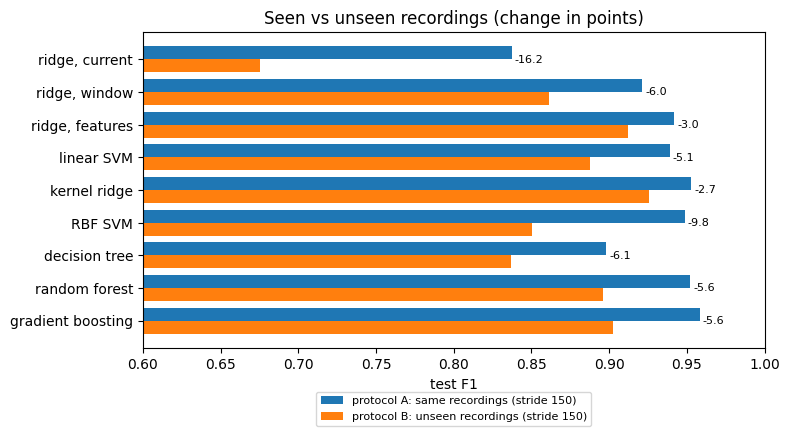

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
yy = np.arange(len(cmp_b))
ax.barh(yy - 0.2, cmp_b["F1 A (stride 150)"], 0.4, label="protocol A: same recordings (stride 150)")
ax.barh(yy + 0.2, cmp_b["F1 B (stride 150)"], 0.4, label="protocol B: unseen recordings (stride 150)")
for i, (a, b) in enumerate(zip(cmp_b["F1 A (stride 150)"], cmp_b["F1 B (stride 150)"])):
    ax.text(max(a, b) + 0.002, i, f"{100 * (b - a):+.1f}", va="center", fontsize=8)
ax.set_yticks(yy, cmp_b.index); ax.invert_yaxis(); ax.set_xlim(0.6, 1.0); ax.set_xlabel("test F1")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=8)
ax.set_title("Seen vs unseen recordings (change in points)"); plt.tight_layout(); plt.show()

In [8]:
# per test recording, protocol B (whole recording) vs protocol A (its last 15%), stride 150
sel = ["ridge_feat_all", "krr_feat_all", "rf_feat_all", "gb_feat_all"]
recB = pd.DataFrame({SHORT[m]: per_recording(b150[m][1], test_b, y_b) for m in sel})
recA = pd.DataFrame({SHORT[m]: per_recording(s150[m][1], test_ends, y_test) for m in sel}).loc[TEST_RECS_B]
pd.concat({"B (unseen)": recB, "A (seen, last 15%)": recA}, axis=1).round(3)

B (unseen)                             \
                      ridge, features kernel ridge random forest   
air_jumping_gait                0.009        0.001         0.000   
concrete_pronking               0.862        0.884         0.798   
concrete_right_circle           0.967        0.971         0.975   
forest                          0.929        0.939         0.938   
small_pebble                    0.936        0.944         0.949   

                                        A (seen, last 15%)               \
                      gradient boosting    ridge, features kernel ridge   
air_jumping_gait                  0.001              0.000        0.000   
concrete_pronking                 0.813              0.952        0.970   
concrete_right_circle             0.976              0.958        0.965   
forest                            0.941              0.932        0.947   
small_pebble                      0.950              0.953        0.962   

                                                       
                      random forest gradient boosting  
air_jumping_gait              0.000             0.000  
concrete_pronking             0.975             0.980  
concrete_right_circle         0.969             0.974  
forest                        0.944             0.951  
small_pebble                  0.964             0.963

In [9]:
pd.DataFrame({SHORT[m]: {"A": best_params(s150[m][0]), "B": best_params(b150[m][0])} for m in MODELS}).T.rename_axis(
    "chosen hyperparameters (stride 150)")

,A,B
chosen hyperparameters (stride 150),,
"ridge, current",alpha=0.01,alpha=0.001
"ridge, window",alpha=10,alpha=10
"ridge, features",alpha=10,alpha=1
linear SVM,C=0.01,C=0.01
kernel ridge,"alpha=0.1, gamma_scale=0.2","alpha=0.03, gamma_scale=0.2"
RBF SVM,"C=10, gamma_scale=0.3","C=100, gamma_scale=0.3"
decision tree,min_samples_leaf=1,min_samples_leaf=5
random forest,"max_features=0.2, min_samples_leaf=1","max_features=0.1, min_samples_leaf=1"
gradient boosting,"max_iter=400, max_leaf_nodes=63","max_iter=800, max_leaf_nodes=15"


In [10]:
# pronking is the only pronking recording: under protocol B the whole gait is unseen in training
rows = np.concatenate([np.full(len(e), n) for n, e in test_b.items()])
keep = rows != "concrete_pronking"
f1 = lambda p, y: np.mean([f1_score(y[:, k], p[:, k], zero_division=0) for k in range(4)])
print("share of test contacts in concrete_pronking:", round(y_b[~keep].sum() / y_b.sum(), 3))
pd.DataFrame({SHORT[m]: {"F1 B, all 5 recordings": b150[m][0]["test"]["f1"],
                         "F1 B, without pronking": f1(b150[m][1][keep], y_b[keep]),
                         "F1 B, pronking only": f1(b150[m][1][~keep], y_b[~keep]),
                         "F1 A (stride 150)": s150[m][0]["test"]["f1"]} for m in MODELS}).T.round(4)

share of test contacts in concrete_pronking: 0.418


,"F1 B, all 5 recordings","F1 B, without pronking","F1 B, pronking only",F1 A (stride 150)
"ridge, current",0.6757,0.9139,0.2058,0.8373
"ridge, window",0.8611,0.9273,0.7425,0.9211
"ridge, features",0.9120,0.9450,0.8623,0.9418
linear SVM,0.8877,0.9490,0.7928,0.9389
kernel ridge,0.9256,0.9547,0.8839,0.9529
RBF SVM,0.8503,0.9411,0.7050,0.9486
decision tree,0.8367,0.8974,0.7424,0.8981
random forest,0.8958,0.9576,0.7981,0.9521
gradient boosting,0.9025,0.9587,0.8128,0.9583


- **Every model loses on unseen recordings**, from −2.7 (kernel ridge) to −16.2 points (ridge on the current timestep).
- **The ranking changes**: kernel ridge is best (0.926), then ridge on features (0.912), boosting (0.903), the forest
  (0.896); the RBF SVM falls to 0.850.
- **Almost the whole drop is one recording: pronking.** `concrete_pronking` is the dataset's only pronking recording,
  so under protocol B **the pronking gait is never seen in training** — and it holds 42% of the test contacts.
  - **Without pronking** the unseen recordings (trot on forest, small pebble, concrete circle; jumping in the air) score
    at the level of protocol A: boosting 0.959, forest 0.958, kernel ridge 0.955, ridge 0.945 — and the protocol A ranking
    returns. **A new terrain with a known gait costs almost nothing**; concrete_right_circle even scores as well as its
    seen last 15%.
  - **On the unseen gait**, the models fitted to all windows with a squared loss generalize best: kernel ridge 0.884,
    ridge on features 0.862; then boosting 0.813, forest 0.798, linear SVM 0.793; the single tree 0.742 and the RBF SVM
    0.705 (validation chose C = 100, weak regularization). Trees predict a constant outside the region they were
    trained on, which here is a whole new gait.
- **The errors are missed contacts, not false ones**: precision stays at 0.95–0.96 for ridge on features, kernel ridge,
  forest and boosting, while recall drops to 0.84–0.90; false contacts stay at 1.9–2.7% (missed: 9.6–16%). On a gait it
  has never seen, the model fails on the safe side for the EKF. Ridge on the current timestep is the exception
  (8.9% false contacts).
- **Validation cannot see this**: validation (seen recordings) scores 0.93–0.96 for every model but ridge on the
  current timestep and the tree, and picks boosting (0.960) — the test
  winner is kernel ridge. Choosing a model for unseen gaits would need validation on held-out recordings.
- Stride 150 only (3.6k training windows); the stride-10 rerun will show whether more windows of the *known* gaits help
  on the unseen one. Comparison with the papers' numbers: with the stride-10 results.

### 2.2 Stride 10

The main configuration: compared with the main protocol A results (`02_results`). Train / val / refit windows:
53,686 / 9,330 / 63,016 (protocol A: 70,476 / 14,882 / 85,358). The `_10k` models are back (kernel models on 10k windows
again): `gb_10k` vs kernel ridge compares the two at equal data.

In [11]:
ALL = MODELS + ["ridge_10k_feat_all", "svm_linear_10k_feat_all", "gb_10k_feat_all"]
a10, b10 = load("", ALL), load("protocol_b", ALL)
cmp_b10 = pd.DataFrame({SHORT[m]: {
    "F1 A": a10[m][0]["test"]["f1"], "F1 B": b10[m][0]["test"]["f1"],
    "change [points]": 100 * (b10[m][0]["test"]["f1"] - a10[m][0]["test"]["f1"]),
    "F1 B stride 150": b150[m][0]["test"]["f1"] if m in b150 else np.nan,
    "F1 B without pronking": f1(b10[m][1][keep], y_b[keep]), "F1 B pronking only": f1(b10[m][1][~keep], y_b[~keep]),
    "val F1 B": max(v["val_f1"] for v in b10[m][0]["validation"]),
    "precision B": b10[m][0]["test"]["precision"], "recall B": b10[m][0]["test"]["recall"],
    "exact-state B": b10[m][0]["test"]["exact"],
    **{f"{k} B": v for k, v in rates(b10[m][1], y_b).items()}} for m in ALL}).T
cmp_b10.round(4)

,F1 A,F1 B,change [points],F1 B stride 150,F1 B without pronking,F1 B pronking only,val F1 B,precision B,recall B,exact-state B,false contact B,missed contact B
"ridge, current",0.8404,0.6747,-16.5706,0.6757,0.9243,0.1861,0.8871,0.7891,0.5897,0.7286,0.0863,0.4103
"ridge, window",0.9297,0.8732,-5.6554,0.8611,0.9345,0.7651,0.9363,0.9315,0.8220,0.8360,0.0330,0.1780
"ridge, features",0.9463,0.9215,-2.4825,0.9120,0.9501,0.8797,0.9428,0.9521,0.8928,0.8766,0.0246,0.1072
linear SVM,0.9519,0.9196,-3.2247,0.8877,0.9564,0.8652,0.9489,0.9539,0.8878,0.8685,0.0236,0.1122
kernel ridge,0.9558,0.9314,-2.4368,0.9256,0.9560,0.8990,0.9542,0.9341,0.9302,0.8527,0.0377,0.0698
RBF SVM,0.9528,0.9263,-2.6587,0.8503,0.9583,0.8793,0.9507,0.9535,0.9008,0.8727,0.0243,0.0992
decision tree,0.9396,0.8560,-8.3616,0.8367,0.9051,0.7748,0.9284,0.8739,0.8417,0.7143,0.0677,0.1583
random forest,0.9668,0.9346,-3.2180,0.8958,0.9664,0.8867,0.9618,0.9710,0.9011,0.8899,0.0150,0.0989
gradient boosting,0.9720,0.9379,-3.4064,0.9025,0.9704,0.8892,0.9672,0.9701,0.9080,0.8878,0.0154,0.0920
"ridge, features, 10k",0.9421,0.9180,-2.4046,NaN,0.9491,0.8730,0.9424,0.9447,0.8929,0.8677,0.0287,0.1071


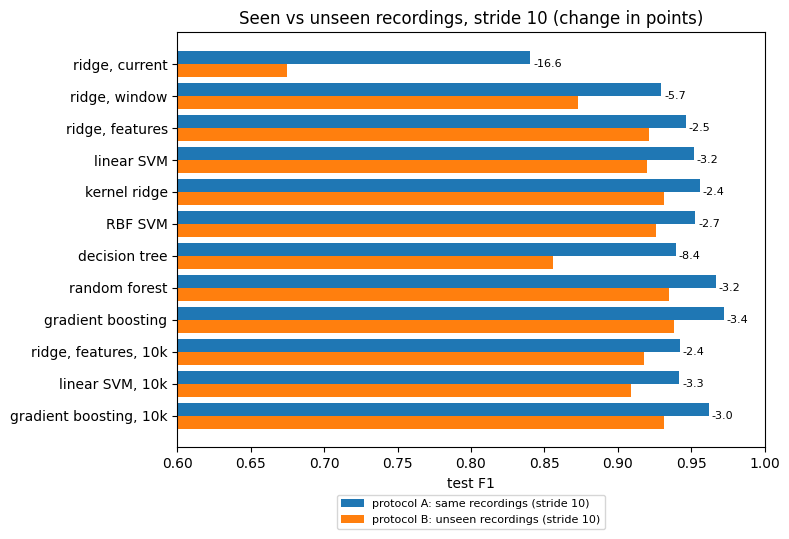

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
yy = np.arange(len(cmp_b10))
ax.barh(yy - 0.2, cmp_b10["F1 A"], 0.4, label="protocol A: same recordings (stride 10)")
ax.barh(yy + 0.2, cmp_b10["F1 B"], 0.4, label="protocol B: unseen recordings (stride 10)")
for i, (a, b) in enumerate(zip(cmp_b10["F1 A"], cmp_b10["F1 B"])):
    ax.text(max(a, b) + 0.002, i, f"{100 * (b - a):+.1f}", va="center", fontsize=8)
ax.set_yticks(yy, cmp_b10.index); ax.invert_yaxis(); ax.set_xlim(0.6, 1.0); ax.set_xlabel("test F1")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1, fontsize=8)
ax.set_title("Seen vs unseen recordings, stride 10 (change in points)"); plt.tight_layout(); plt.show()

In [13]:
sel = ["ridge_feat_all", "krr_feat_all", "rf_feat_all", "gb_10k_feat_all", "gb_feat_all"]
pd.DataFrame({SHORT[m]: per_recording(b10[m][1], test_b, y_b) for m in sel}).round(3).rename_axis(
    "protocol B, stride 10: F1 per test recording (air: false-contact rate)")

,"ridge, features",kernel ridge,random forest,"gradient boosting, 10k",gradient boosting
"protocol B, stride 10: F1 per test recording (air: false-contact rate)",,,,,
air_jumping_gait,0.002,0.012,0.001,0.000,0.001
concrete_pronking,0.880,0.899,0.887,0.882,0.889
concrete_right_circle,0.968,0.974,0.981,0.979,0.983
forest,0.933,0.945,0.950,0.948,0.957
small_pebble,0.938,0.951,0.962,0.960,0.965


In [14]:
pd.DataFrame({SHORT[m]: {"protocol A": best_params(a10[m][0]), "protocol B": best_params(b10[m][0])} for m in ALL}).T.rename_axis(
    "chosen hyperparameters (stride 10)")

,protocol A,protocol B
chosen hyperparameters (stride 10),,
"ridge, current",alpha=0.001,alpha=10
"ridge, window",alpha=0.1,alpha=1
"ridge, features",alpha=0.1,alpha=1
linear SVM,C=0.3,C=0.03
kernel ridge,"alpha=0.03, gamma_scale=0.3","alpha=0.03, gamma_scale=0.3"
RBF SVM,"C=10, gamma_scale=0.3","C=3, gamma_scale=0.3"
decision tree,min_samples_leaf=50,min_samples_leaf=50
random forest,"max_features=0.1, min_samples_leaf=1","max_features=0.1, min_samples_leaf=1"
gradient boosting,"max_iter=800, max_leaf_nodes=63","max_iter=800, max_leaf_nodes=127"


- **Best on unseen recordings: gradient boosting 0.938**, then the forest 0.935, boosting on 10k 0.932, kernel ridge
  0.931, RBF SVM 0.926. Every model loses vs protocol A: −2.4 (kernel ridge, ridge) to −3.4 points (boosting); the single
  tree −8.4 and ridge on the current timestep −16.6.
- **Again, the drop is the unseen gait**: without pronking, boosting scores 0.970 (protocol A: 0.972), the forest 0.966
  (0.967), kernel ridge 0.956 (0.956). A new terrain with a known gait costs ~nothing.
- **On the unseen gait (pronking)**: kernel ridge 0.899 is still best, then boosting 0.889, the forest 0.887, boosting
  on 10k 0.882, ridge 0.880, RBF SVM 0.879; the single tree 0.775, ridge on the raw window 0.765, ridge on the current
  timestep 0.186.
- **More windows of the known gaits help on the unknown one too** (stride 150 → 10, pronking only): boosting 0.813 →
  0.889, forest 0.798 → 0.887, kernel ridge 0.884 → 0.899; overall RBF SVM 0.850 → 0.926. The stride-150 result
  "kernel ridge generalizes best" was largely data scarcity: with enough data the ensembles come within ~1 point of it on
  pronking and win overall.
- **Equal data (10k windows): boosting and kernel ridge tie** (0.932 vs 0.931; under protocol A boosting led by 0.6).
  Boosting's lead on unseen recordings comes from the extra data it can use (10k → 63k: 0.932 → 0.938).
- **Errors are again mostly missed contacts**: boosting and the forest keep precision at 0.97 and false contacts at
  1.5% (protocol A: 1.6–1.8%), recall 0.90–0.91. **Kernel ridge is the exception**: highest recall (0.930) but 3.8%
  false contacts (protocol A: 2.5%) — its best pronking score comes with more of the harmful error.
- **Validation now agrees with test** at the top (boosting 0.967, forest 0.962 on validation; same order on test) —
  unlike at stride 150.
- Hyperparameters mostly as in protocol A; slightly stronger regularization for the linear models (ridge α 0.1 → 1,
  linear SVM C 0.3 → 0.03) and bigger trees for boosting (63 → 127 leaves).

### 2.3 Comparison with the published results on this split

Published numbers: MS-HGNN paper (arXiv 2412.01297, Table 2), mean ± std over 4 runs. Deep networks on the raw
150 × 54 window, ~635k train+val windows (stride 1), trained on train with early stopping on validation. Same metrics as
ours: legs-avg F1 = our macro per-leg F1; 16-state accuracy = our exact-state accuracy.

In [15]:
papers = pd.DataFrame({"CNN (Lin et al. 2021)": (0.861, 0.004, 0.731, 0.013), "CNN-Aug (C2)": (0.873, 0.007, 0.778, 0.019),
                       "ECNN (C2)": (0.871, 0.011, 0.788, 0.029), "MI-HGNN (S4)": (0.931, 0.005, 0.870, 0.010),
                       "MS-HGNN (K4)": (0.939, 0.006, 0.875, 0.012)},
                      index=["legs-avg F1", "± F1", "16-state accuracy", "± accuracy"]).T
ours = pd.DataFrame({f"ours: {SHORT[m]} (stride {s})": {"legs-avg F1": r[m][0]["test"]["f1"],
                                                         "16-state accuracy": r[m][0]["test"]["exact"]}
                     for s, r, ms in [(10, b10, ["gb_feat_all", "rf_feat_all", "krr_feat_all", "svm_rbf_feat_all", "ridge_feat_all"]),
                                      (150, b150, ["krr_feat_all"])] for m in ms}).T
pd.concat([papers, ours]).round(3)

,legs-avg F1,± F1,16-state accuracy,± accuracy
CNN (Lin et al. 2021),0.861,0.004,0.731,0.013
CNN-Aug (C2),0.873,0.007,0.778,0.019
ECNN (C2),0.871,0.011,0.788,0.029
MI-HGNN (S4),0.931,0.005,0.870,0.010
MS-HGNN (K4),0.939,0.006,0.875,0.012
ours: gradient boosting (stride 10),0.938,NaN,0.888,NaN
ours: random forest (stride 10),0.935,NaN,0.890,NaN
ours: kernel ridge (stride 10),0.931,NaN,0.853,NaN
ours: RBF SVM (stride 10),0.926,NaN,0.873,NaN
"ours: ridge, features (stride 10)",0.921,NaN,0.877,NaN


- **Gradient boosting on hand-crafted features is level with the best published model**: legs-avg F1 0.938 vs
  MS-HGNN 0.939 ± 0.006 (within its run-to-run spread), above MI-HGNN 0.931 ± 0.005. On 16-state accuracy boosting
  (0.888) and the forest (0.890) are above both (0.870, 0.875).
- **+7.7 points over the dataset paper's CNN** (0.861) and +6.7 over the symmetry-equivariant ECNN (0.871).
- Kernel ridge matches MI-HGNN's F1 (0.931) but has a lower 16-state accuracy (0.853): it makes more false contacts
  (3.8%), and one wrong leg is enough to miss the state.
- With ~10× fewer training windows than the papers (63k at stride 10 vs ~635k at stride 1) and no neural network,
  classical models on good features reach the graph neural networks.
- **Not a perfectly matched comparison**: we drop the last 300 ms of each recording (label artefact) and score windows
  from timestep 150 on; we refit on train+val (they train on train, early stopping on validation); one deterministic run
  vs their mean of 4 seeds; their CNN/ECNN predict the 16 states jointly. Differences below ~1 point should not be
  over-read.